In [1]:
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.datasets import fetch_covtype
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, log_loss
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch import Tensor

import torch._dynamo
import torch.utils.benchmark as benchmark
from torch.optim import Optimizer
from torchinfo import summary
from torch.autograd import Function

In [2]:
def zeropower_via_newtonschulz5(G: Tensor, steps: int) -> Tensor:
    assert G.ndim >= 2
    a, b, c = 3.4445, -4.7750, 2.0315
    X = G.clone().float()
    if G.size(-2) > G.size(-1):
        X = X.mT
    X = X / (X.norm(dim=(-2, -1), keepdim=True) + 1e-7)
    for _ in range(steps):
        A = X @ X.mT
        B = b * A + c * A @ A
        X = a * X + B @ X
    if G.size(-2) > G.size(-1):
        X = X.mT
    return X

class Muon(Optimizer):
    def __init__(self, params, lr=0.02, weight_decay=0.01, momentum=0.95, nesterov=True, ns_steps=5):
        defaults = dict(lr=lr, weight_decay=weight_decay, momentum=momentum, nesterov=nesterov, ns_steps=ns_steps)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            lr = group["lr"]
            weight_decay = group["weight_decay"]
            momentum = group["momentum"]
            nesterov = group["nesterov"]
            ns_steps = group["ns_steps"]

            for p in group["params"]:
                if p.grad is None:
                    continue
                g = p.grad.data

                if g.ndim < 2:
                    continue  # skip scalars, biases, etc.

                state = self.state[p]
                if "momentum_buffer" not in state:
                    state["momentum_buffer"] = torch.zeros_like(g)

                buf = state["momentum_buffer"]
                buf.mul_(momentum).add_(g)

                if nesterov:
                    g = g + momentum * buf
                else:
                    g = buf

                if g.ndim == 4:
                    g = g.view(g.size(0), -1)

                g = zeropower_via_newtonschulz5(g, steps=ns_steps).view_as(p)

                p.mul_(1 - lr * weight_decay)
                p.add_(g, alpha=-lr)

In [3]:
torch._dynamo.config.cache_size_limit = 16

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device = torch.device("cpu")

In [4]:
df = sns.load_dataset('diamonds')
df = df[['carat', 'depth', 'table', 'price', 'x', 'y', 'z', 'cut']]

df['cut'] = (df['cut'] == 'Ideal').astype(int)

X = df.drop('cut', axis=1)
y = df['cut']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long).to(device)

print(X.shape)
print(y.shape)

ideal_percentage = df['cut'].mean() * 100
print(f"Percentage of diamonds with 'Ideal' cut: {ideal_percentage:.2f}%")

model = LogisticRegression(penalty='l2', C=0.001, max_iter=10000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

y_pred_proba = model.predict_proba(X_test)
loss = log_loss(y_test, y_pred_proba)

print(f"Test Accuracy: {accuracy * 100:.2f}%")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Ideal', 'Ideal']))
print(model.coef_)
print(f"Log Loss: {loss:.6f}")

(53940, 7)
(53940,)
Percentage of diamonds with 'Ideal' cut: 39.95%
Test Accuracy: 79.30%
Classification Report:
              precision    recall  f1-score   support

   Not Ideal       0.82      0.85      0.83      6496
       Ideal       0.75      0.71      0.73      4292

    accuracy                           0.79     10788
   macro avg       0.79      0.78      0.78     10788
weighted avg       0.79      0.79      0.79     10788

[[-0.15688782 -0.46189194 -1.57368125  0.22509094 -0.08309788 -0.03167662
  -0.08671039]]
Log Loss: 0.451068


/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered

In [5]:
def train(model, criterion, optimizers, epochs):
    print(summary(model, input_data=X_train_tensor))

    torch.set_printoptions(threshold=float('inf'))
    for name, param in model.named_parameters():
        print(name)
        print(param)

    @torch._dynamo.explain
    def run_model(x):
        return model(x)

    run_model(X_train_tensor) # type: ignore

    best_test_loss = float('inf')

    train_losses = []
    test_losses = []

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    schedulers = [
        torch.optim.lr_scheduler.LinearLR(opt, start_factor=1.0, end_factor=0.05, total_iters=epochs)
        for opt in optimizers
    ]

    for epoch in range(1, epochs + 1):
        model.train()
        for opt in optimizers:
            opt.zero_grad()

        train_outputs = model(X_train_tensor)
        train_loss = criterion(train_outputs, y_train_tensor)
        train_loss.backward()

        for opt in optimizers:
            opt.step()

        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test_tensor)
            test_loss = criterion(test_outputs, y_test_tensor)
            test_predictions = torch.argmax(test_outputs, dim=1)
            test_accuracy = (test_predictions == y_test_tensor).sum().item() / y_test_tensor.size(0)

        train_losses.append(train_loss.item())
        test_losses.append(test_loss.item())

        if test_loss.item() < best_test_loss:
            best_test_loss = test_loss.item()

        for scheduler in schedulers:
            scheduler.step()

        if epoch % 1 == 0:
            print(f"Epoch {epoch}/{epochs}, Train Loss: {train_loss.item():.32f}, Test Loss: {test_loss.item():.8f}, Test Accuracy: {test_accuracy:.4f}")

    if torch.cuda.is_available():
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

        print(f"[GPU] Peak memory allocated: {torch.cuda.max_memory_allocated() / 1024 ** 2:.2f} MB")
        print(f"[GPU] Peak memory reserved: {torch.cuda.max_memory_reserved() / 1024 ** 2:.2f} MB")

    print()
    print(f"Lowest Test Loss: {best_test_loss:.8f}")

    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Test Loss Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()  

In [ ]:
class DeepFeedforwardFixedPReLU(nn.Module):
    def __init__(self, input_size=7, hidden_sizes=[64, 64, 64], output_size=2):
        super(DeepFeedforwardFixedPReLU, self).__init__()

        layers = []
        in_size = input_size

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(in_size, hidden_size))
            
            # PReLU with alpha initialized to 1
            prelu = nn.PReLU(init=0.0)
            # Freeze alpha parameter
            # for param in prelu.parameters():
            #     param.requires_grad = False
            layers.append(prelu)

            in_size = hidden_size

        layers.append(nn.Linear(in_size, output_size))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

Muon parameters:
torch.Size([64, 7])
torch.Size([64, 64])
torch.Size([64, 64])
torch.Size([2, 64])

AdamW parameters:
torch.Size([64])
torch.Size([1])
torch.Size([64])
torch.Size([1])
torch.Size([64])
torch.Size([1])
torch.Size([2])
Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─DeepFeedforwardFixedPReLU: 1-1         [43152, 2]                --
│    └─Sequential: 2-1                   [43152, 2]                --
│    │    └─Linear: 3-1                  [43152, 64]               512
│    │    └─PReLU: 3-2                   [43152, 64]               1
│    │    └─Linear: 3-3                  [43152, 64]               4,160
│    │    └─PReLU: 3-4                   [43152, 64]               1
│    │    └─Linear: 3-5                  [43152, 64]               4,160
│    │    └─PReLU: 3-6                   [43152, 64]               1
│    │    └─Linear: 3-7                  [43152, 2]       

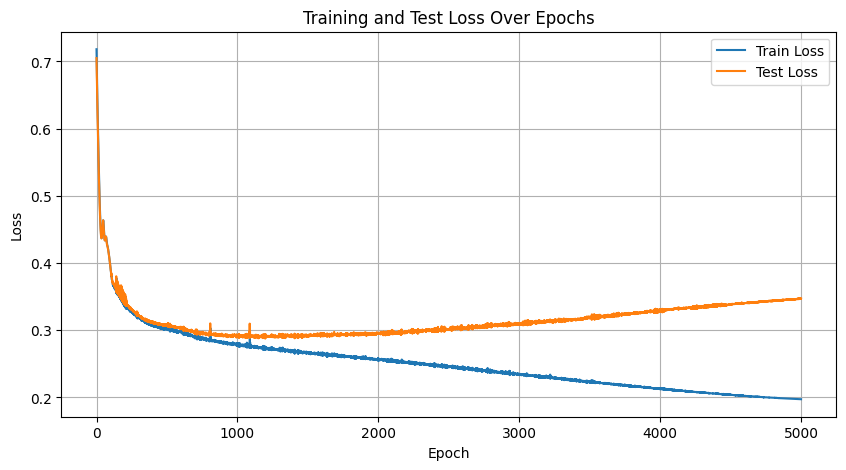

_orig_mod.network.0.weight
Parameter containing:
tensor([[-1.7969e-01, -2.4215e-01, -2.8706e-01,  9.9498e-01, -1.4879e+00,
          6.0530e-01,  7.4471e-01],
        [ 4.2267e-01, -1.6398e-01,  2.4568e-02,  1.2149e-01, -1.3690e+00,
         -1.2303e+00,  1.3772e+00],
        [-3.2661e-01,  1.6253e-01, -7.1046e-02,  3.7157e-03,  1.2074e+00,
         -2.4302e+00,  1.6738e+00],
        [-1.1336e-01, -5.3443e-01,  2.3997e-01,  6.2751e-01, -1.1929e+00,
          1.8709e+00, -8.5650e-01],
        [-9.2828e-02,  6.5860e-02, -5.0668e-02, -6.2382e-01, -9.7765e-01,
         -6.9449e-02,  1.2563e+00],
        [-7.1520e-01, -6.1892e-01,  1.7133e-02,  8.2585e-02,  2.6853e+00,
         -1.0084e+00, -1.1060e+00],
        [ 3.3228e-01, -7.4441e-01,  2.6823e-02, -7.4472e-01, -2.9579e-01,
          9.7490e-02,  7.6833e-01],
        [-1.1652e+00,  1.2972e-01,  2.3484e-01,  3.1836e-01,  4.2301e-01,
          1.0641e+00, -1.4494e+00],
        [ 4.8885e-01, -8.6398e-02, -1.3045e-01, -8.2963e-01,  1.2008e+0

In [8]:
model = torch.compile(DeepFeedforwardFixedPReLU().to(device))
criterion = nn.CrossEntropyLoss()

muon_params = []
adamw_params = []

for name, param in model.named_parameters(): # type: ignore
    if (param.ndim >= 2):
        muon_params.append(param)
    else:
        adamw_params.append(param)

print("Muon parameters:")
for p in muon_params:
    print(p.shape)

print()
print("AdamW parameters:")
for p in adamw_params:
    print(p.shape)

optimizers = [
    Muon(muon_params, weight_decay=0.0),
    optim.AdamW(adamw_params, weight_decay=0.0)
]

train(model, criterion, optimizers, epochs=5000)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Muon parameters:
torch.Size([7, 14])
torch.Size([14, 28])
torch.Size([28, 56])
torch.Size([2, 112])

AdamW parameters:
torch.Size([2])
Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                --
│    └─BatchNorm1d: 2-1                  [43152, 7]                --
│    └─CReLU: 2-2                        [43152, 14]               --
│    └─ModuleList: 2-13                  --                        --
│    │    └─BatchNorm1d: 3-1             [43152, 14]               --
│    └─ModuleList: 2-14                  --                        (recursive)
│    │    └─Linear: 3-2                  [43152, 7]                98
│    └─ModuleList: 2-15                  --                        --
│    │    └─BatchNorm1d: 3-3             [43152, 7]                --
│    └─ModuleList: 2-16                  --                        --
│    │    └

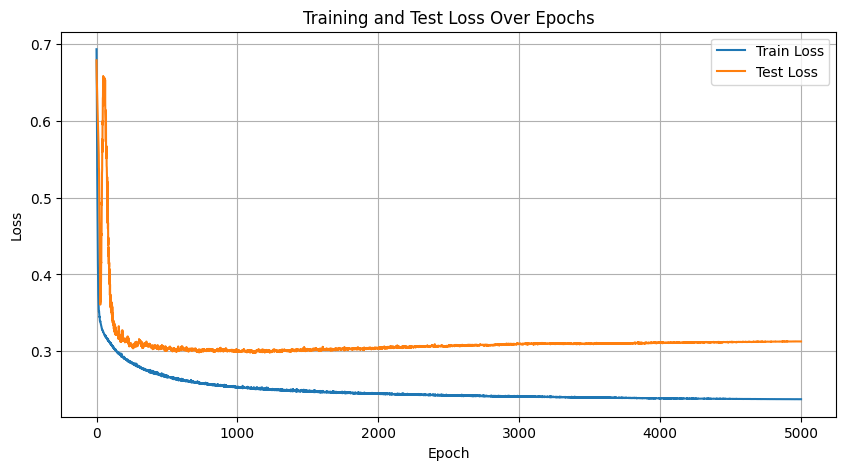

_orig_mod.linears.0.weight
Parameter containing:
tensor([[-0.3226,  0.5494,  1.4438, -0.4536, -1.2193, -0.5756, -0.4195, -1.4275,
          0.5229,  0.0509,  0.6246, -0.2336,  0.5169,  1.7000],
        [-0.6358,  0.5240, -0.8274, -0.4145, -0.3418, -0.5465,  1.4570,  1.7271,
         -0.5361, -0.8232,  0.3163,  0.1736, -2.1185,  0.4473],
        [-0.2397,  2.2451,  0.5930, -0.3705,  0.9042, -0.5748,  0.0667,  0.8778,
          1.2061,  1.1897, -0.0209, -1.4963, -0.2285,  1.0297],
        [ 0.1121, -0.2657,  0.3559, -0.4999,  1.9031, -0.1913,  0.8555,  1.4838,
          0.5939, -0.9652, -0.9859,  1.4985, -1.6456, -0.2882],
        [-0.4516, -0.3316,  0.2553, -0.0302, -0.4907, -1.7968, -0.3850,  0.2302,
         -0.2901, -0.4607,  0.0198, -0.9330,  2.5381,  0.7006],
        [-0.1482,  0.1019,  0.6112, -0.0391, -1.9899,  0.5851, -0.2096,  0.7466,
          0.0738, -1.1768, -0.1051,  0.4942,  0.7226, -0.1771],
        [-0.8546, -0.8410,  1.7356, -0.7786, -0.2339,  0.5758,  1.1760,  0.6502,


In [13]:
# postnorm(postnomrm(x) + residual)

model = torch.compile(StableNN(n=X.shape[1], num_layers=3).to(device))
criterion = nn.CrossEntropyLoss()

muon_params = []
adamw_params = []

for name, param in model.named_parameters(): # type: ignore
    if (param.ndim >= 2):
        muon_params.append(param)
    else:
        adamw_params.append(param)

print("Muon parameters:")
for p in muon_params:
    print(p.shape)

print()
print("AdamW parameters:")
for p in adamw_params:
    print(p.shape)

optimizers = [
    Muon(muon_params, weight_decay=0.0),
    optim.AdamW(adamw_params, weight_decay=0.0)
]

train(model, criterion, optimizers, epochs=5000)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

In [11]:
# postnorm(postnomrm(x) + residual)

model = torch.compile(StableNN(n=X.shape[1], num_layers=3).to(device))
criterion = nn.CrossEntropyLoss()

muon_params = []
adamw_params = []

for name, param in model.named_parameters(): # type: ignore
    if (param.ndim >= 2):
        muon_params.append(param)
    else:
        adamw_params.append(param)

print("Muon parameters:")
for p in muon_params:
    print(p.shape)

print()
print("AdamW parameters:")
for p in adamw_params:
    print(p.shape)

optimizers = [
    Muon(muon_params, weight_decay=0.0),
    optim.AdamW(adamw_params, weight_decay=0.0)
]

train(model, criterion, optimizers, epochs=5000)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Muon parameters:
torch.Size([7, 14])
torch.Size([14, 28])
torch.Size([28, 56])
torch.Size([2, 112])

AdamW parameters:
torch.Size([2])
Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                --
│    └─BatchNorm1d: 2-1                  [43152, 7]                --
│    └─CReLU: 2-2                        [43152, 14]               --
│    └─ModuleList: 2-11                  --                        --
│    │    └─BatchNorm1d: 3-1             [43152, 14]               --
│    └─ModuleList: 2-12                  --                        (recursive)
│    │    └─Linear: 3-2                  [43152, 7]                98
│    └─ModuleList: 2-13                  --                        --
│    │    └─BatchNorm1d: 3-3             [43152, 7]                --
│    │    └─BatchNorm1d: 3-4             [43152, 7]                --
│    └─CReL

KeyboardInterrupt: 